# Lab Day 2 — Backbone, công thức huấn luyện và suy luận trên DeepWeeds

Notebook **khung** cho Colab hoặc Kaggle. Các ô có chữ `TODO` là phần **bạn tự viết**; ô cài đặt, tải dữ liệu
và chạy `eval.py` đã viết sẵn. Đọc `README.md` (quy tắc chia dữ liệu, cách đánh giá), `GUIDE.md` và `RUBRIC.md` trước.

**Quy tắc quan trọng nhất:** chọn mọi thứ trên **val**; **test chỉ chạy một lần mỗi seed ở Bước 4**.

Bản đồ: Bước 0 (EDA, kiểm tra) → Bước 1 (backbone) → Bước 2 (công thức huấn luyện) → Bước 3 (suy luận)
→ Bước 4 (chung kết + `eval.py`) → Bước 5 (xlsx, biểu đồ, báo cáo).

## 0. Cài đặt môi trường

In [1]:
# Cài thư viện (Colab/Kaggle). Kaggle: bật Internet trong Settings.
!pip -q install timm openpyxl

import sys, os, platform
import numpy as np, pandas as pd, torch, timm

# Đã `git clone` repo bài lab vào thư mục này (đổi nếu bạn đặt chỗ khác).
REPO_DIR = "K4-DAY02-BuiVietAnh-2A202602611"
sys.path.insert(0, REPO_DIR)                 # để import eval.py
sys.path.insert(0, f"{REPO_DIR}/submissions/2A202602611_BuiVietAnh/code")    # hoặc thư mục code/ của bạn sau khi chép starter vào

print("python", platform.python_version(), "| torch", torch.__version__, "| timm", timm.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "KHÔNG CÓ GPU")


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
f:\lab-d2p2\K4-DAY02-BuiVietAnh-2A202602611\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


python 3.11.9 | torch 2.14.1+cu126 | timm 1.0.30
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


### Tải dữ liệu (đã viết sẵn)
Ảnh từ Zenodo (~490 MB, kiểm tra MD5), nhãn và các file chia fold từ GitHub của tác giả.
**Sau khi giải nén, hãy `ls` để xem ảnh nằm ở thư mục nào** rồi đặt `IMAGES_DIR` cho đúng.

In [2]:
import hashlib

os.makedirs("data/labels", exist_ok=True)
if not os.path.exists("data/images.zip"):
    !wget -q -O data/images.zip "https://zenodo.org/records/7939060/files/images.zip?download=1"

h = hashlib.md5()
with open("data/images.zip", "rb") as f:
    for chunk in iter(lambda: f.read(1 << 20), b""):
        h.update(chunk)
assert h.hexdigest() == "b7b30f96d466fba86016aa5a26606e0f", f"MD5 sai: {h.hexdigest()}"

!unzip -q -n data/images.zip -d data/
!ls data | head

BASE = "https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels"
for name in ["labels", "train_subset0", "val_subset0", "test_subset0"]:
    !wget -q -O data/labels/{name}.csv {BASE}/{name}.csv
!ls -la data/labels

'wget' is not recognized as an internal or external command,
operable program or batch file.


FileNotFoundError: [Errno 2] No such file or directory: 'data/images.zip'

In [ ]:
IMAGES_DIR = "data/images"   # Thư mục chứa các file ảnh
LABELS_DIR = "data/labels"

## Bước 0 — EDA và kiểm tra pipeline
Mục tiêu: hiểu dữ liệu, chạy các kiểm tra chia dữ liệu (README mục 2.1), kiểm tra pipeline trước khi chạy thật.

train: 10,501 ảnh (59.97%)
val: 3,501 ảnh (20.00%)
test: 3,507 ảnh (20.03%)
                train   val  test
Chinee Apple      675   225   226
Lantana           637   213   213
Parkinsonia       618   206   207
Parthenium        613   204   205
Prickly Acacia    637   212   213
Rubber Vine       605   202   202
Siam Weed         644   215   215
Snake Weed        609   203   204
Negatives        5463  1821  1822
Tổng: 17,509 ảnh; giao giữa các tập: {'train_val': 0, 'train_test': 0, 'val_test': 0}


,train,val,test,Total
Class,,,,
Chinee Apple,675,225,226,1126
Lantana,637,213,213,1063
Parkinsonia,618,206,207,1031
Parthenium,613,204,205,1022
Prickly Acacia,637,212,213,1062
Rubber Vine,605,202,202,1009
Siam Weed,644,215,215,1074
Snake Weed,609,203,204,1016
Negatives,5463,1821,1822,9106


,Observed,Table 1,Difference
Class,,,
Chinee Apple,1126,1125,1
Lantana,1063,1064,-1
Parkinsonia,1031,1031,0
Parthenium,1022,1022,0
Prickly Acacia,1062,1062,0
Rubber Vine,1009,1009,0
Siam Weed,1074,1074,0
Snake Weed,1016,1016,0
Negatives,9106,9106,0


Counts differ from Table 1; check the source CSVs before training.
Negatives account for 52.01%; the class distribution is imbalanced.


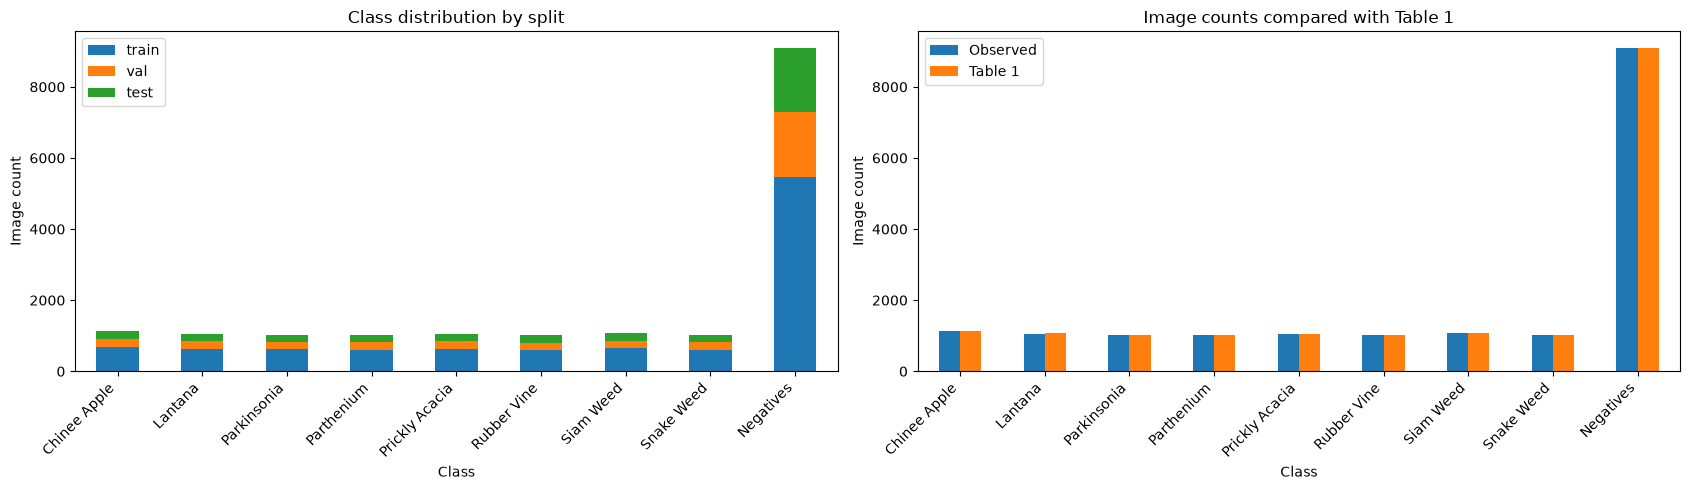

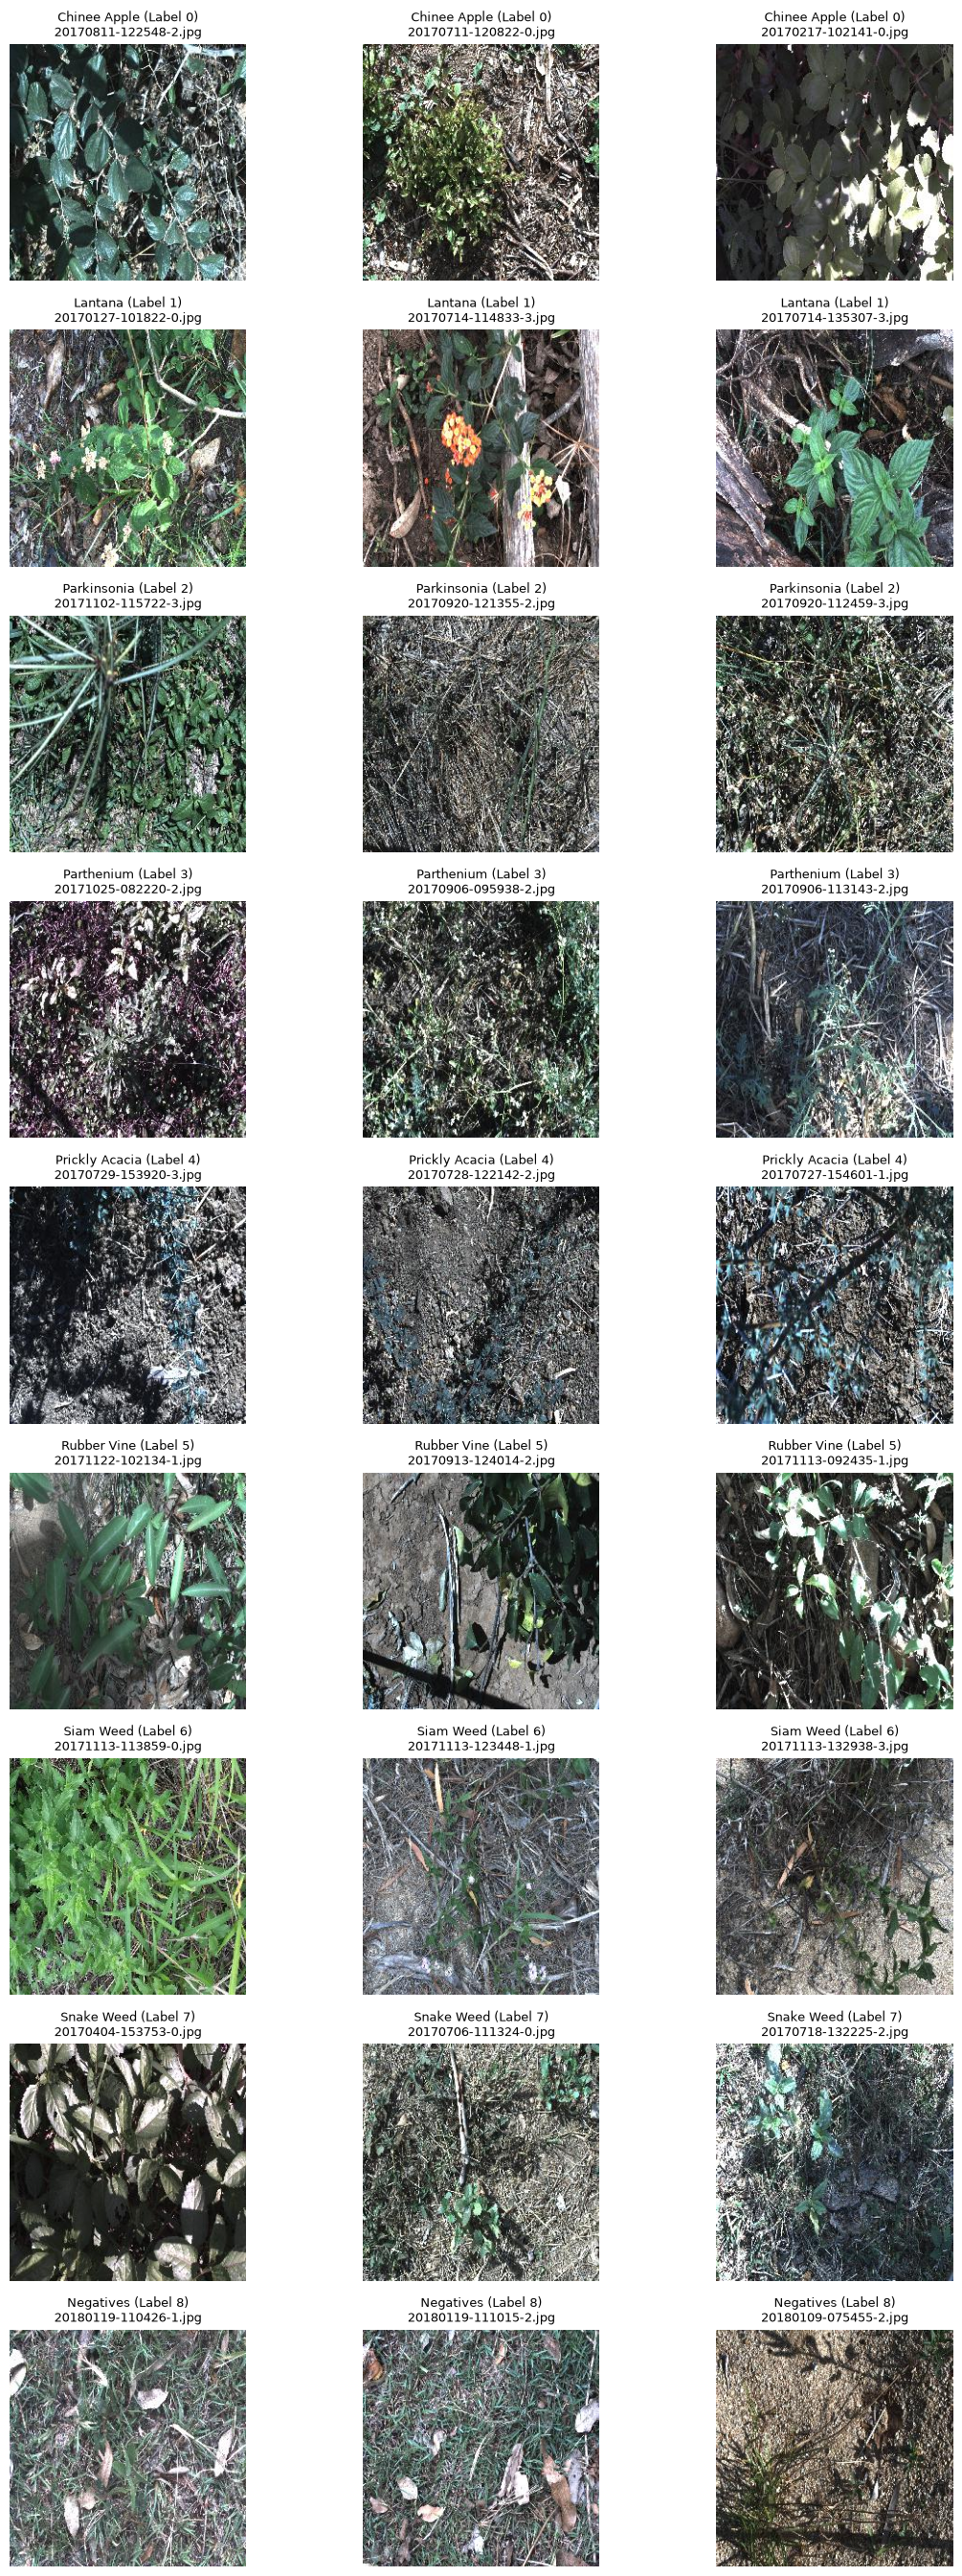

In [5]:
from pathlib import Path
import importlib
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
import dataset

# Reload dataset.py after edits in this notebook session.
importlib.reload(dataset)
train_df, val_df, test_df = dataset.load_split(LABELS_DIR, fold=0)
split_stats = dataset.check_split(train_df, val_df, test_df, IMAGES_DIR)

# Preserve Label order 0-8, including classes absent from a split.
class_counts = pd.DataFrame(split_stats["per_class"]).reindex(range(dataset.NUM_CLASSES))
class_counts.index = pd.Index(dataset.CLASS_NAMES, name="Class")
class_counts["Total"] = class_counts.sum(axis=1)
display(class_counts)

# Table 1 counts reproduced in the lab README.md.
table1_counts = [1125, 1064, 1031, 1022, 1062, 1009, 1074, 1016, 9106]
comparison = pd.DataFrame({"Observed": class_counts["Total"], "Table 1": table1_counts})
comparison["Difference"] = comparison["Observed"] - comparison["Table 1"]
display(comparison)
if comparison["Difference"].eq(0).all():
    print("All 9 class counts match Table 1 (17,509 images).")
else:
    print("Counts differ from Table 1; check the source CSVs before training.")
negative_share = class_counts.loc["Negatives", "Total"] / class_counts["Total"].sum()
print(f"Negatives account for {negative_share:.2%}; the class distribution is imbalanced.")

fig, axes = plt.subplots(1, 2, figsize=(17, 5))
class_counts[["train", "val", "test"]].plot.bar(stacked=True, ax=axes[0])
axes[0].set_title("Class distribution by split")
axes[0].set_ylabel("Image count")
comparison[["Observed", "Table 1"]].plot.bar(ax=axes[1])
axes[1].set_title("Image counts compared with Table 1")
axes[1].set_ylabel("Image count")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
    for tick in ax.get_xticklabels():
        tick.set_horizontalalignment("right")
fig.tight_layout()
plt.show()

# Show original training images with a fixed sampling seed.
images_per_class = 3
fig, axes = plt.subplots(dataset.NUM_CLASSES, images_per_class, figsize=(12, 27))
for label, class_name in enumerate(dataset.CLASS_NAMES):
    candidates = train_df.loc[train_df["Label"].eq(label)]
    if len(candidates) < images_per_class:
        raise ValueError(f"{class_name}: train has fewer than {images_per_class} images")
    samples = candidates.sample(n=images_per_class, random_state=42)
    for column, filename in enumerate(samples["Filename"]):
        ax = axes[label, column]
        with Image.open(Path(IMAGES_DIR) / filename) as image:
            ax.imshow(image.convert("RGB"))
        ax.set_title(f"{class_name} (Label {label})\n{filename}", fontsize=9)
        ax.axis("off")
fig.tight_layout()
plt.show()


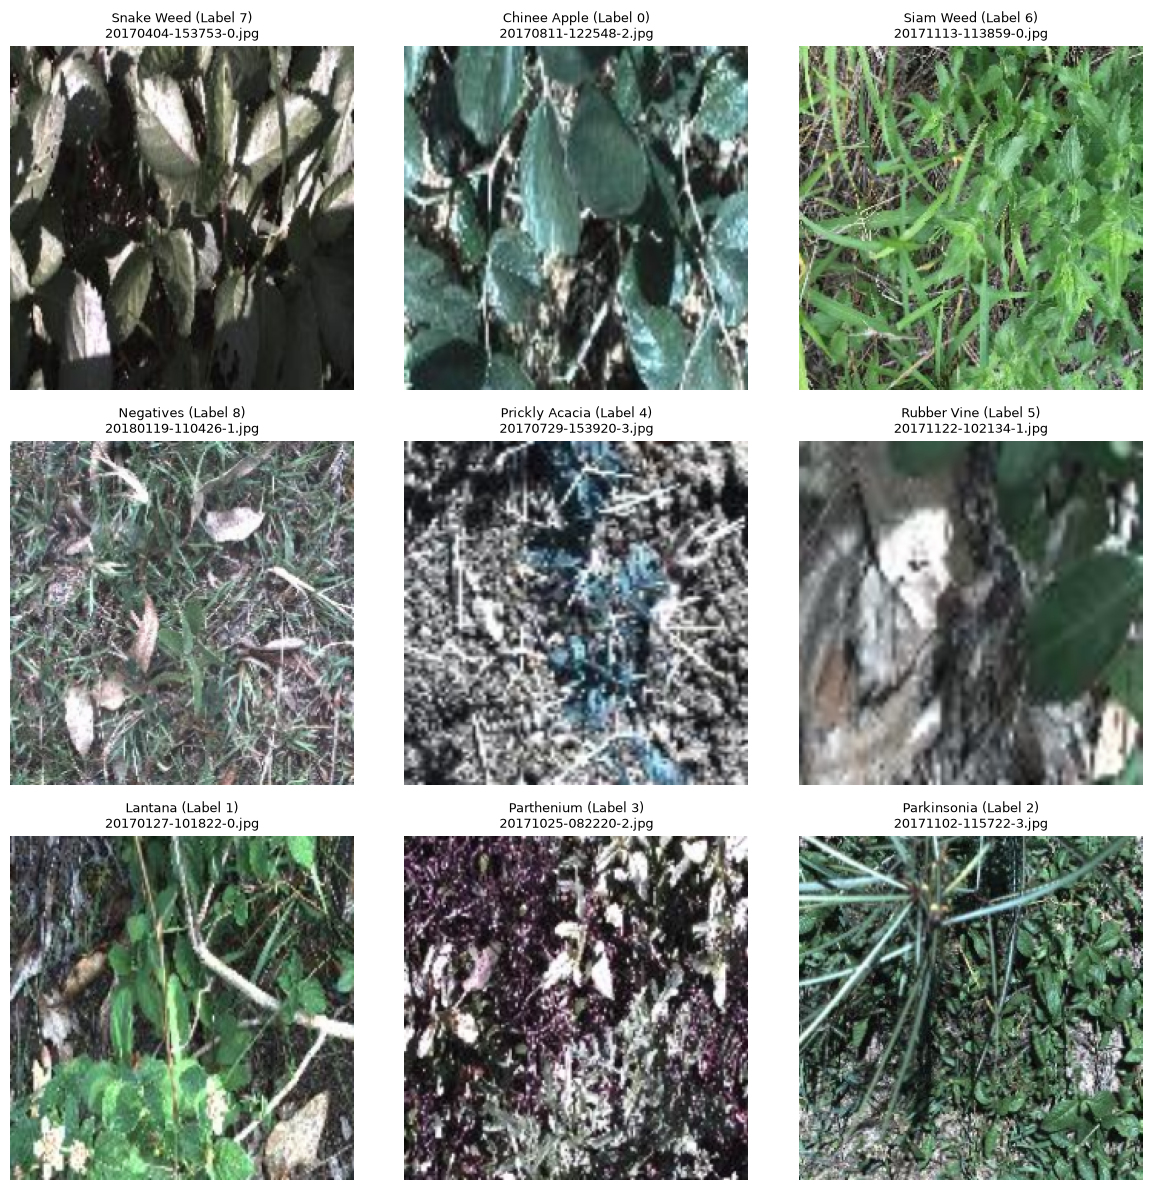

f:\lab-d2p2\K4-DAY02-BuiVietAnh-2A202602611\.venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\vieta\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
f:\lab-d2p2\K4-DAY02-BuiVietAnh-2A202602611\.venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingf

Thiết bị: cuda; CE ban đầu = 2.2072; mốc ln(9) = 2.1972
Bước   1: CE = 2.19057, đúng 0%
Bước  25: CE = 0.70270, đúng 100%


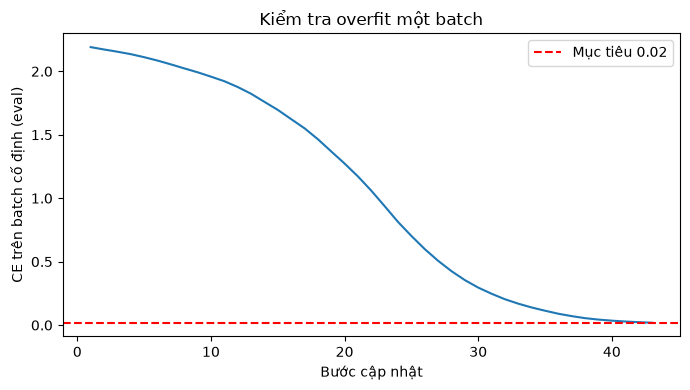

Kết quả: 43 bước; CE = 0.01891; đúng 100%
Các kiểm tra tự động đã đạt. Hãy xem thêm ảnh augmentation để xác nhận bằng mắt.


In [6]:
# Kiểm tra pipeline trước khi chạy thí nghiệm thật (GUIDE.md mục 1.3).
import math
import importlib
import torch
import dataset
import model as model_utils
import train

# Reload để notebook nhận các thay đổi vừa sửa trong file .py.
for module in (dataset, model_utils, train):
    importlib.reload(module)

SEED = 42
BACKBONE = "resnet50"
PRETRAINED = True  # Lần đầu cần Internet để tải trọng số ImageNet.
IMG_SIZE = 224
MAX_STEPS = 300
TARGET_LOSS = 0.02  # Ngưỡng thực hành cho loss gần 0.
train.set_seed(SEED)  # Cố định random, NumPy, PyTorch và cách tính trên GPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
evidence_dir = Path("curves")
evidence_dir.mkdir(parents=True, exist_ok=True)

# Chọn đúng một ảnh mỗi lớp từ TRAIN: batch nhỏ có đủ cả 9 nhãn.
# Chọn đủ lớp giúp phát hiện lỗi tốt hơn một batch chỉ có lớp Negatives.
small_df = pd.concat([
    train_df.loc[train_df["Label"].eq(label)].sample(n=1, random_state=SEED)
    for label in range(dataset.NUM_CLASSES)
], ignore_index=True)
small_loader = dataset.make_loader(
    small_df, IMAGES_DIR,
    dataset.build_transforms(train=True, img_size=IMG_SIZE, aug="basic"),
    batch_size=len(small_df), train=True, num_workers=0,
)
# num_workers=0 dễ chạy trên notebook/Windows; make_loader cũng đã seed worker
# cho trường hợp bạn tăng num_workers ở các thí nghiệm sau.
images, labels, filenames = next(iter(small_loader))
assert images.shape == (dataset.NUM_CLASSES, 3, IMG_SIZE, IMG_SIZE)
assert torch.isfinite(images).all(), "Ảnh chứa NaN hoặc vô cực"
assert labels.dtype == torch.long and set(labels.tolist()) == set(range(9))

# 4) Vẽ CHÍNH batch sau augmentation mà model sẽ học, kèm nhãn và tên file.
# Normalize tính (ảnh - mean)/std; đảo lại bằng ảnh * std + mean.
mean = torch.tensor(dataset.IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(dataset.IMAGENET_STD).view(3, 1, 1)
display_images = (images * std + mean).clamp(0, 1)
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for index, ax in enumerate(axes.flat):
    label = int(labels[index])
    # Dataset phải giữ ảnh, nhãn, tên file từ cùng một dòng CSV.
    expected_label = int(small_df.set_index("Filename").loc[filenames[index], "Label"])
    assert label == expected_label, f"Nhãn lệch với CSV: {filenames[index]}"
    ax.imshow(display_images[index].permute(1, 2, 0).numpy())
    ax.set_title(f"{dataset.CLASS_NAMES[label]} (Label {label})\n{filenames[index]}", fontsize=9)
    ax.axis("off")
fig.tight_layout()
fig.savefig(evidence_dir / "pipeline_augmented.png", dpi=150)
plt.show()
# Vẫn cần nhìn ảnh để xác nhận crop có giữ vùng cây và nhãn có hợp lý.

# Model riêng cho kiểm tra; không dùng trọng số đã overfit cho thí nghiệm thật.
check_model = model_utils.build_model(
    BACKBONE, pretrained=PRETRAINED, num_classes=dataset.NUM_CLASSES,
    drop_rate=0.0, init="finetune",
).to(device)
images, labels = images.to(device), labels.to(device)
criterion = torch.nn.CrossEntropyLoss()  # CE thường, không smoothing hay trọng số lớp.

# 2) Đo head mới TRƯỚC khi học; eval tắt dropout và giữ thống kê BatchNorm.
check_model.eval()
with torch.no_grad():
    logits = check_model(images)
    assert logits.shape == (len(labels), dataset.NUM_CLASSES)
    initial_loss = criterion(logits, labels).item()
expected_loss = math.log(dataset.NUM_CLASSES)  # -ln(1/9) = ln(9).
print(f"Thiết bị: {device}; CE ban đầu = {initial_loss:.4f}; mốc ln(9) = {expected_loss:.4f}")
# Head ngẫu nhiên không nhất thiết chia xác suất đều, nên đây là mốc xấp xỉ.
# Không gán head bằng 0 để ép loss bằng 2.197: cần đo khởi tạo thật.
assert math.isfinite(initial_loss), "Loss ban đầu không hữu hạn"
assert abs(initial_loss - expected_loss) < 0.5, (
    "CE ban đầu lệch nhiều: kiểm tra logits, head, nhãn và chuẩn hoá ảnh."
)

# 3) Học lặp lại CÙNG tensor của một batch, không crop/lật lại mỗi bước.
# Bỏ weight decay và các cách làm khó việc nhớ batch để tìm lỗi cơ bản trước.
head_ids = {id(parameter) for parameter in check_model.get_classifier().parameters()}
optimizer = torch.optim.AdamW([
    {"params": [p for p in check_model.parameters() if id(p) not in head_ids], "lr": 1e-4},
    {"params": list(check_model.get_classifier().parameters()), "lr": 1e-3},
], weight_decay=0.0)
loss_history = []
check_model.train()  # Bật chế độ học cho bài kiểm tra toàn bộ model.
for step in range(1, MAX_STEPS + 1):
    optimizer.zero_grad(set_to_none=True)  # Xoá gradient (mức thay đổi cần học) bước trước.
    loss = criterion(check_model(images), labels)
    assert torch.isfinite(loss).item(), f"Loss không hữu hạn ở bước {step}"
    loss.backward()  # Tính mức thay đổi cần áp dụng cho từng trọng số.
    optimizer.step()  # Cập nhật trọng số để giảm loss.

    # Đo lại SAU cập nhật ở eval: kiểm tra cả cách model sẽ dùng khi dự đoán.
    check_model.eval()
    with torch.no_grad():
        predictions = check_model(images)
        measured_loss = criterion(predictions, labels).item()
        accuracy = (predictions.argmax(dim=1) == labels).float().mean().item()
    assert math.isfinite(measured_loss), f"Loss eval không hữu hạn ở bước {step}"
    loss_history.append(measured_loss)
    check_model.train()
    if step == 1 or step % 25 == 0:
        print(f"Bước {step:3d}: CE = {measured_loss:.5f}, đúng {accuracy:.0%}")
    if measured_loss <= TARGET_LOSS and accuracy == 1.0:
        break

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(loss_history) + 1), loss_history)
ax.axhline(TARGET_LOSS, color="red", linestyle="--", label=f"Mục tiêu {TARGET_LOSS}")
ax.set(xlabel="Bước cập nhật", ylabel="CE trên batch cố định (eval)", title="Kiểm tra overfit một batch")
ax.legend()
fig.tight_layout()
fig.savefig(evidence_dir / "pipeline_overfit.png", dpi=150)
plt.show()
print(f"Kết quả: {len(loss_history)} bước; CE = {measured_loss:.5f}; đúng {accuracy:.0%}")
assert measured_loss <= TARGET_LOSS and accuracy == 1.0, (
    "Chưa overfit được batch: kiểm tra gradient, LR, dữ liệu và model trước khi train thật."
)

# Giải phóng model kiểm tra; seed lại trước khi tạo model của thí nghiệm thật.
del optimizer, loss, logits, predictions, check_model, images, labels
if torch.cuda.is_available():
    torch.cuda.empty_cache()
train.set_seed(SEED)
print("Các kiểm tra tự động đã đạt. Hãy xem thêm ảnh augmentation để xác nhận bằng mắt.")


## Bước 1 — So sánh backbone (≥ 5)
Cùng công thức nền `T00` (GUIDE.md mục 1.4), cùng seed, mỗi backbone một lần chạy. Mã thí nghiệm `B01`, `B02`, ...

In [ ]:
# TODO: vòng lặp qua danh sách backbone, mỗi lần gọi train.run(Config(exp_id="B01", backbone=..., seed=0))
#       Gợi ý: from train import Config, run
# TODO: ghi vào bảng: tag trọng số, #params, GMAC, macro-F1 val, top-1 val, thời gian train/epoch.
# TODO: chọn 1-2 backbone đi tiếp, kèm lý do dựa trên số liệu.

## Bước 2 — Công thức huấn luyện (≥ 3 trục)
Mỗi lần chạy chỉ khác `T00` **một yếu tố**. Mã `T01`, `T02`, ... Ghi rõ khác ở điểm nào.

In [ ]:
# TODO: các trục A-G của GUIDE.md mục 3 (khởi tạo, augmentation, loss, sampler, LR/optimizer, EMA, ...).
# TODO: thử ít nhất một kết hợp các yếu tố tốt; so Δ với nhiễu (std).

## Bước 3 — Suy luận (≥ 4 phương pháp) và độ trễ
Làm trên **val**. Không huấn luyện lại. Mã `I00` (1 view, mốc), `I01`, ...

In [ ]:
# TODO: TTA lật, multi-crop/scale, dò độ phân giải, gộp xác suất vs logit, ensemble, EMA/soup,
#       temperature scaling (T khớp trên VAL), gộp BN/FP16  (starter/inference.py)
# TODO: độ trễ p50/p95/p99 bằng starter/benchmark.py: warmup, synchronize, >= 50 lần

## Bước 4 — Chung kết: ≥ 3 seed, test một lần mỗi seed
1. Chốt cấu hình trên **val**.
2. Chạy cấu hình cuối **và mốc** (`T00` + `I00`) với cùng số seed, bật `save_test_predictions=True`.
3. Dự đoán lưu ở `predictions/<exp_id>_seed<k>_test.csv`. Rồi chạy `eval.py` (ô dưới).

In [ ]:
# TODO: chạy chung kết và mốc, mỗi seed, ví dụ:
#   for seed in (0, 1, 2):
#       run(Config(exp_id="F01", ..., seed=seed, save_test_predictions=True))
#       run(Config(exp_id="T00", seed=seed, save_test_predictions=True))
# Với suy luận (TTA/ensemble/temperature scaling), tự ghi predictions/F01_seed<k>_test.csv
# bằng eval.save_predictions(...) từ xác suất cuối cùng; thêm F01uncal_* nếu muốn chấm I4(a).

In [ ]:
# Tính chỉ số theo đúng định nghĩa của lớp (đã viết sẵn, không sửa eval.py):
!python {REPO_DIR}/eval.py score --pred "predictions/F01_seed*_test.csv" \
    --test-csv {LABELS_DIR}/test_subset0.csv --labels {LABELS_DIR}/labels.csv --tag F01 --out eval_out
!python {REPO_DIR}/eval.py score --pred "predictions/T00_seed*_test.csv" \
    --test-csv {LABELS_DIR}/test_subset0.csv --labels {LABELS_DIR}/labels.csv --tag T00 --out eval_out

In [ ]:
# Tự chấm phần I của RUBRIC (đề xuất, giảng viên xác nhận). Thêm --uncal, --final-val, --latency-p95-ms nếu có.
!python {REPO_DIR}/eval.py grade --final "predictions/F01_seed*_test.csv" \
    --baseline "predictions/T00_seed*_test.csv" \
    --test-csv {LABELS_DIR}/test_subset0.csv --labels {LABELS_DIR}/labels.csv --out eval_out

## Bước 5 — Sản phẩm
`results.xlsx` (các sheet ở GUIDE.md mục 6.1), `curves/<exp_id>_*.png`, `report.md`, `predictions/`, `code/`.

In [ ]:
# TODO: ghi results.xlsx bằng pandas.ExcelWriter(engine="openpyxl") với các sheet:
#   Backbones, Training, Inference, Final, PerClass, Latency, Summary
# TODO: kiểm tra mỗi exp_id có ảnh trong curves/ và số trong xlsx khớp kết quả của eval.py